In [ ]:
%pip install plotly 
%pip install numpy

In [1]:
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats


# 1. Load both files and label them
sponsored = pd.read_csv("zenodo-data/sponsored_posts.csv")
unsponsored = pd.read_csv("zenodo-data/unsponsored_posts.csv")
sponsored["Sponsored"] = "TRUE"
sponsored["group"] = "Sponsored"

unsponsored["Sponsored"] = "FALSE"
unsponsored["group"] = "Unsponsored"

# 2. Stack them into one table
posts = pd.concat([sponsored, unsponsored])

# 3. Drop accounts with missing or zero followers (can't divide by them)
posts = posts[posts["user_followers"] > 0]

# Create the engagment rate. 
posts["engagement_rate"] = (posts["likes"] + posts["comments"]) / posts["user_followers"]

In [3]:
posts.head()

,user_id,user_followers,likes,comments,id,Sponsored,group,engagement_rate
0,179037181,1634.0,81,5,2297742899655135745,TRUE,Sponsored,0.052632
1,25783801241,95.0,3,1,2297738413553416176,TRUE,Sponsored,0.042105
2,32030939764,526.0,8,0,2297715524791715348,TRUE,Sponsored,0.015209
3,14288521,75570.0,419,17,2297709946912814555,TRUE,Sponsored,0.005769
4,2025150409,149.0,2,0,2297705923349356813,TRUE,Sponsored,0.013423


# A Most simple Statistical T-Test

In [2]:


# We need two separate groups because we want to compare them.
#
# Group 1: Sponsored posts
# Group 2: Unsponsored posts

sponsored = posts.loc[
    posts["group"] == "Sponsored",
    "engagement_rate"
]

unsponsored = posts.loc[
    posts["group"] == "Unsponsored",
    "engagement_rate"
]


In [4]:
# The mean tells us the average engagement for each group.
#
# This is a descriptive statistic:
# it tells us what happened in this dataset,
# but it does NOT tell us if the difference is statistically meaningful.

print(
    f"Average sponsored engagement: {sponsored.mean():,.4f}"
)

print(
    f"Average unsponsored engagement: {unsponsored.mean():,.4f}"
)

Average sponsored engagement: 0.0766
Average unsponsored engagement: 0.0843


In [5]:
# A Welch's t-test compares the averages of two groups.
#
# Our question:
#
# "Is the average engagement of sponsored posts
# statistically different from unsponsored posts?"
#
# The test creates:
#
# Null hypothesis (H0):
#     Sponsored and unsponsored posts have the same average engagement.
#
# Alternative hypothesis (H1):
#     Sponsored and unsponsored posts have different average engagement.
#
# We use Welch's t-test because it does not assume
# both groups have the same amount of variation.

result = stats.ttest_ind(
    sponsored,
    unsponsored,
    equal_var=False
)

print(
    f"t-statistic: {result.statistic:.4f}"
)

print(
    f"p-value: {result.pvalue:.6f}"
)



t-statistic: -4.0061
p-value: 0.000062


# Inspect engagement rates

In [7]:
import pandas as pd
import numpy as np
import plotly.express as px

from data_profiling import ProfileReport


fig = px.histogram(posts['engagement_rate'], log_y=True)


fig.update_layout(
    yaxis_title="Count of Users that Have this engagment level",
    xaxis_title="Engagment Level"
)

fig.show()

In [9]:

# 5. Put each post into a follower bucket
bins = [0, 5_000, 10_000, 25_000, 50_000, 75_000, 100_000, 150_000, 250_000, 500_000, 1_000_000, float("inf")]
labels = ["0-5K", "5K-10K", "10K-25K", "25K-50K", "50K-75K", "75K-100K",
          "100K-150K", "150K-250K", "250K-500K", "500K-1M", "1M+"]
posts["follower_bucket"] = pd.cut(posts["user_followers"], bins=bins, labels=labels).astype(str)


In [10]:
posts.groupby('follower_bucket')['engagement_rate'].agg(['count', 'mean', 'median'])

,count,mean,median
follower_bucket,,,
0-5K,43773,0.098507,0.041045
100K-150K,890,0.009579,0.004123
10K-25K,4700,0.024058,0.014078
150K-250K,390,0.016004,0.007840
1M+,144,0.009082,0.003166
250K-500K,249,0.016179,0.009380
25K-50K,2141,0.019872,0.010375
500K-1M,201,0.016213,0.007167
50K-75K,888,0.014500,0.008188


In [11]:

# 6. Box plot: one pair of boxes (sponsored vs not) per bucket
fig = px.box(posts, x="follower_bucket", y="engagement_rate", color="Sponsored",
             category_orders={"follower_bucket": labels, "Sponsored": ["FALSE", "TRUE"]},
             color_discrete_map={"FALSE": "#8f8e89", "TRUE": "#2a78d6"},
             points="outliers",
             labels={"follower_bucket": "Follower Bucket", "engagement_rate": "Engagement Rate"})
fig.update_traces(marker_opacity=0)  # hide outlier dots; whiskers stop at 1.5 x IQR
fig.update_yaxes(range=[0, 0.15])
fig.show()

In [12]:
def do_test(posts, label=None):

    if label:
        print(label)

    sponsored = posts.loc[
        posts["group"] == "Sponsored",
        "engagement_rate"
    ]

    unsponsored = posts.loc[
        posts["group"] == "Unsponsored",
        "engagement_rate"
    ]

    print(
        f"Average sponsored engagement: {sponsored.mean():,.4f}"
    )

    print(
        f"Average unsponsored engagement: {unsponsored.mean():,.4f}"
    )


    result = stats.ttest_ind(
        sponsored,
        unsponsored,
        equal_var=False
    )

    print(
        f"t-statistic: {result.statistic:.4f}"
    )

    print(
        f"p-value: {result.pvalue:.6f}"
    )

In [13]:
posts.head()

low_bucket = posts[posts.follower_bucket == "0-5K"].copy()


labels = ["0-5K", "5K-10K", "10K-25K", "25K-50K", "50K-75K", "75K-100K",
          "100K-150K", "150K-250K", "250K-500K", "500K-1M", "1M+"]

for label in labels:
    print(label)
    tmp_df = posts[posts.follower_bucket == label].copy()
    do_test(tmp_df)
    print("#"*79)

0-5K
Average sponsored engagement: 0.1055
Average unsponsored engagement: 0.0934
t-statistic: 5.1018
p-value: 0.000000
###############################################################################
5K-10K
Average sponsored engagement: 0.0376
Average unsponsored engagement: 0.0191
t-statistic: 9.2100
p-value: 0.000000
###############################################################################
10K-25K
Average sponsored engagement: 0.0279
Average unsponsored engagement: 0.0118
t-statistic: 11.5888
p-value: 0.000000
###############################################################################
25K-50K
Average sponsored engagement: 0.0228
Average unsponsored engagement: 0.0102
t-statistic: 8.4485
p-value: 0.000000
###############################################################################
50K-75K
Average sponsored engagement: 0.0160
Average unsponsored engagement: 0.0065
t-statistic: 8.0523
p-value: 0.000000
#########################################################################

<Axes: >

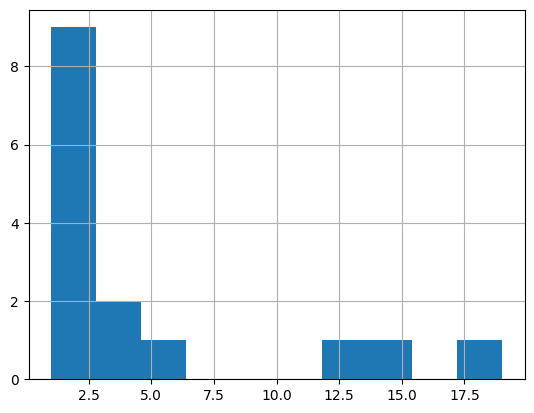

In [15]:
posts[posts.engagement_rate > 5]['user_followers'].hist()